<a href="https://colab.research.google.com/github/pd-25/ML-algorithm-implements/blob/main/naive_bayes/spam_sms_naive_byes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv('spam.csv',encoding='latin-1')


In [ ]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2760,ham,I dont thnk its a wrong calling between us,NaN,NaN,NaN
3467,ham,yay! finally lol. i missed our cinema trip las...,NaN,NaN,NaN
3182,ham,Dunno i juz askin cos i got a card got 20% off...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
4507,ham,Not able to do anything.,NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)


In [ ]:
df.sample(5)

,v1,v2
3419,spam,"As a valued customer, I am pleased to advise y..."
3449,ham,Ya just telling abt tht incident..
2510,ham,Yunny i'm walking in citylink now Ì_ faster co...
1634,spam,"Eerie Nokia tones 4u, rply TONE TITLE to 8007 ..."
3514,ham,I'm job profile seems like bpo..


In [ ]:
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)

In [ ]:
df.sample(5)

,target,text
1854,ham,They did't play one day last year know even th...
4139,ham,Leave it wif me lar... ÌÏ wan to carry meh so ...
5329,ham,"Sir, waiting for your letter."
3263,ham,I will send them to your email. Do you mind &...
3180,ham,So many people seems to be special at first si...


In [ ]:
#If there are messy data like 'hum', ' hum ', 'HUm' then use this below
# df['target_col'] = df['target_col'].str.strip().str.lower().map({'yes': True, 'no': False})

# df['target'].value_counts()
#as we check suing value_count, the data is only 2 type and clean so we use pandas labelencoder
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [ ]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.isnull().sum()

,0
target,0
text,0


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df.drop_duplicates(keep="first", inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['target'].value_counts()

,count
target,
0,4516
1,653


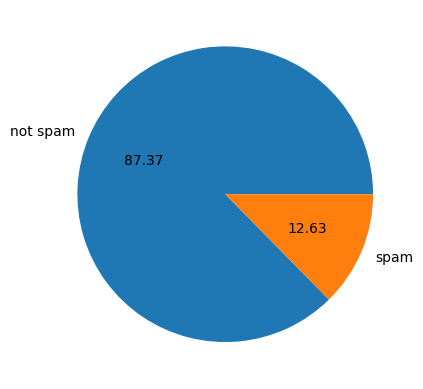

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['not spam', 'spam'], autopct="%0.2f")
plt.show()

In [ ]:
#As we get data is imbalanced
#lets create few more column for better performance

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df['num_characters'] = df['text'].apply(len)

In [ ]:
df.sample(5)

,target,text,num_characters
2032,0,"Yes, i'm small kid.. And boost is the secret o...",59
3893,1,Dear Dave this is your final notice to collect...,153
4823,0,Not thought bout it... || Drink in tap & spile...,111
4883,0,For many things its an antibiotic and it can b...,113
2293,0,Hello. Damn this christmas thing. I think i ha...,91


In [ ]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [ ]:
df.head(5)

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


# Now Data Preprocessing
1. Lower case
2. Tokenization (nltk.word_tokenize)
3. Removing Special char
4. Removing stop words and pantuatons (nltk corpus stop words and string pantuations)
5. stemming (nltk stem)

In [ ]:
import string
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
from nltk.corpus import stopwords
def transform_text(text: str):
  text = text.lower()
  text = nltk.word_tokenize(text)
  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))
  return " ".join(y)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
transform_text('Hello, this is not a &% spamming happening comment?')

'hello spam happen comment'

In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)

In [ ]:
df.sample(5)

,target,text,num_characters,num_words,num_sentences,transformed_text
2999,0,Id onluy matters when getting on from offcampus,47,8,1,id onluy matter get offcampu
4472,0,S but not able to sleep.,24,7,1,abl sleep
2543,0,Package all your programs well,30,5,1,packag program well
1705,0,Yun ah.now Ì_ wkg where?btw if Ì_ go nus sc. Ì...,71,19,2,yun wkg btw go nu sc ìï wana specialis wad
2500,0,Remember to ask alex about his pizza,36,7,1,rememb ask alex pizza


Now we basically work with target and transformed_text feature going forward, we still have the other colm, if we need to to do any bacatrack.

# Now will create a word cloud to highlight which word spam is mostly used here

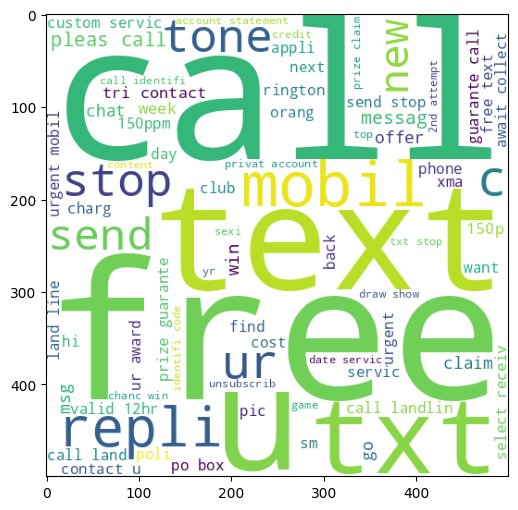

In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

# Now we need on spam colums, use the generate function on spam transformed_text
# df[df['target']==1]['transformed_text']

wc_spam = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(wc_spam)

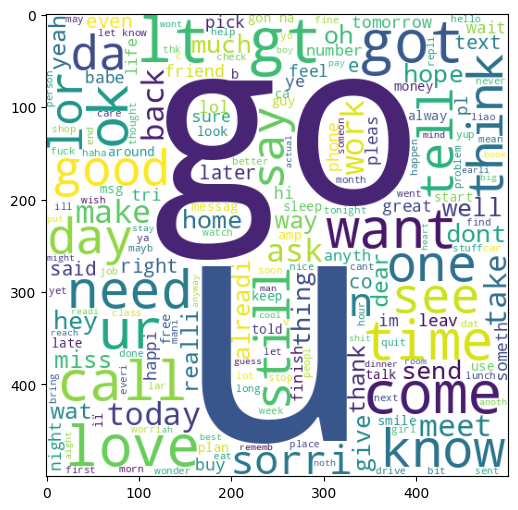

In [ ]:
#Now check for ham msg
wc_ham = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(wc_ham)

# Now Model bulding

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

# X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [ ]:
X.shape

(5169, 6708)

In [ ]:
y = df['target'].values

In [ ]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(f"accuracy_score: {accuracy_score(y_test, y_pred1)}")
print(f"confusion_matrix: {confusion_matrix(y_test, y_pred1)}")
print(f"precision_score: {precision_score(y_test, y_pred1)}")

accuracy_score: 0.8762088974854932
confusion_matrix: [[793 103]
 [ 25 113]]
precision_score: 0.5231481481481481


In [ ]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(f"accuracy_score: {accuracy_score(y_test, y_pred2)}")
print(f"confusion_matrix: {confusion_matrix(y_test, y_pred2)}")
print(f"precision_score: {precision_score(y_test, y_pred2)}")

accuracy_score: 0.9593810444874274
confusion_matrix: [[896   0]
 [ 42  96]]
precision_score: 1.0


In [ ]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(f"accuracy_score: {accuracy_score(y_test, y_pred3)}")
print(f"confusion_matrix: {confusion_matrix(y_test, y_pred3)}")
print(f"precision_score: {precision_score(y_test, y_pred3)}")

accuracy_score: 0.9700193423597679
confusion_matrix: [[893   3]
 [ 28 110]]
precision_score: 0.9734513274336283


In [ ]:
# SO we have checked with both bag of words and tfidfs, we found tfidf with multinomial naive bayse is giving good accuricy and precision
#score also, here the precision_score is preferrable, so we will choose - tfidf with multinomial naive bayse

In [ ]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))
#model has been loded